In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
np.random.seed(42)

n = 1500

df = pd.DataFrame({
    "Employee_ID": range(1001, 1001 + n),

    "Department": np.random.choice(
        ["Engineering", "Sales", "Marketing", "HR",
         "Finance", "Customer Support"],
        n
    ),

    "Location": np.random.choice(
        ["California", "Texas", "New York",
         "Virginia", "Washington", "Remote"],
        n
    ),

    "Job_Level": np.random.choice(
        ["Entry", "Mid", "Senior", "Manager"],
        n,
        p=[0.30, 0.35, 0.25, 0.10]
    ),

    "Age": np.random.randint(21, 60, n),

    "Years_At_Company": np.random.randint(
        0, 16, n
    ),

    "Monthly_Income": np.random.randint(
        30000, 160000, n
    ),

    "Job_Satisfaction": np.random.randint(
        1, 6, n
    ),

    "Work_Life_Balance": np.random.randint(
        1, 6, n
    ),

    "Overtime": np.random.choice(
        ["Yes", "No"],
        n,
        p=[0.35, 0.65]
    ),

    "Remote_Work": np.random.choice(
        ["Yes", "No"],
        n,
        p=[0.45, 0.55]
    )
})

print("Synthetic workforce dataset created!")
print("Shape:", df.shape)

df.head()

Synthetic workforce dataset created!
Shape: (1500, 11)


,Employee_ID,Department,Location,Job_Level,Age,Years_At_Company,Monthly_Income,Job_Satisfaction,Work_Life_Balance,Overtime,Remote_Work
0,1001,HR,Remote,Senior,57,10,37435,5,5,Yes,Yes
1,1002,Finance,Texas,Mid,58,10,97084,2,5,Yes,No
2,1003,Marketing,Virginia,Mid,22,15,154023,1,2,No,Yes
3,1004,Finance,New York,Entry,56,0,100601,4,2,Yes,Yes
4,1005,Finance,Washington,Entry,46,11,118416,4,4,No,No


In [3]:
risk = (
    (df["Overtime"] == "Yes").astype(int) * 2
    + (df["Job_Satisfaction"] <= 2).astype(int) * 2
    + (df["Work_Life_Balance"] <= 2).astype(int) * 2
    + (df["Years_At_Company"] <= 2).astype(int)
    + (df["Years_At_Company"] >= 10).astype(int)
)

probability = 1 / (1 + np.exp(-(risk - 4)))

df["Attrition"] = np.random.binomial(
    1,
    probability
)

df["Attrition"] = df["Attrition"].map({
    0: "No",
    1: "Yes"
})

print(df["Attrition"].value_counts())

Attrition
No     1000
Yes     500
Name: count, dtype: int64


In [4]:
print("Number of Employees:", len(df))
print("Number of Columns:", len(df.columns))

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Records:")
print(df.duplicated().sum())

print("\nDataset Information:")
df.info()

Number of Employees: 1500
Number of Columns: 12

Missing Values:
Employee_ID          0
Department           0
Location             0
Job_Level            0
Age                  0
Years_At_Company     0
Monthly_Income       0
Job_Satisfaction     0
Work_Life_Balance    0
Overtime             0
Remote_Work          0
Attrition            0
dtype: int64

Duplicate Records:
0

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Employee_ID        1500 non-null   int64 
 1   Department         1500 non-null   object
 2   Location           1500 non-null   object
 3   Job_Level          1500 non-null   object
 4   Age                1500 non-null   int64 
 5   Years_At_Company   1500 non-null   int64 
 6   Monthly_Income     1500 non-null   int64 
 7   Job_Satisfaction   1500 non-null   int64 
 8   Work_Life_Balance  1

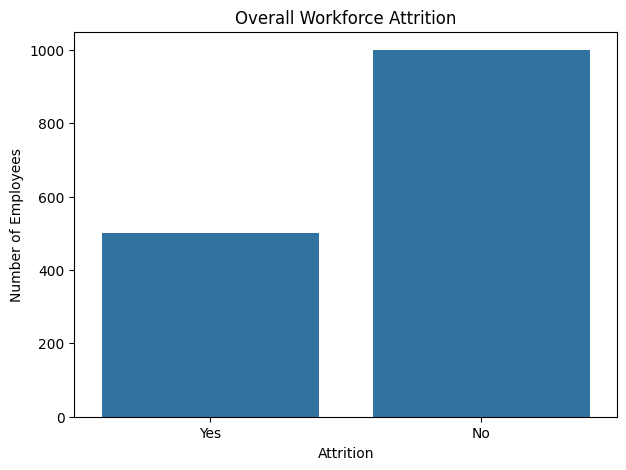

Attrition
No     1000
Yes     500
Name: count, dtype: int64


In [5]:
attrition_count = df["Attrition"].value_counts()

plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Attrition"
)

plt.title("Overall Workforce Attrition")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")

plt.show()

print(attrition_count)

In [6]:
attrition_rate = (
    df["Attrition"].value_counts(normalize=True)
    * 100
)

print("Workforce Attrition Rate:")
print(
    round(attrition_rate.get("Yes", 0), 2),
    "%"
)

Workforce Attrition Rate:
33.33 %


In [7]:
department_analysis = pd.crosstab(
    df["Department"],
    df["Attrition"]
)

department_analysis

Attrition,No,Yes
Department,,
Customer Support,166,82
Engineering,184,82
Finance,166,87
HR,163,85
Marketing,155,88
Sales,166,76


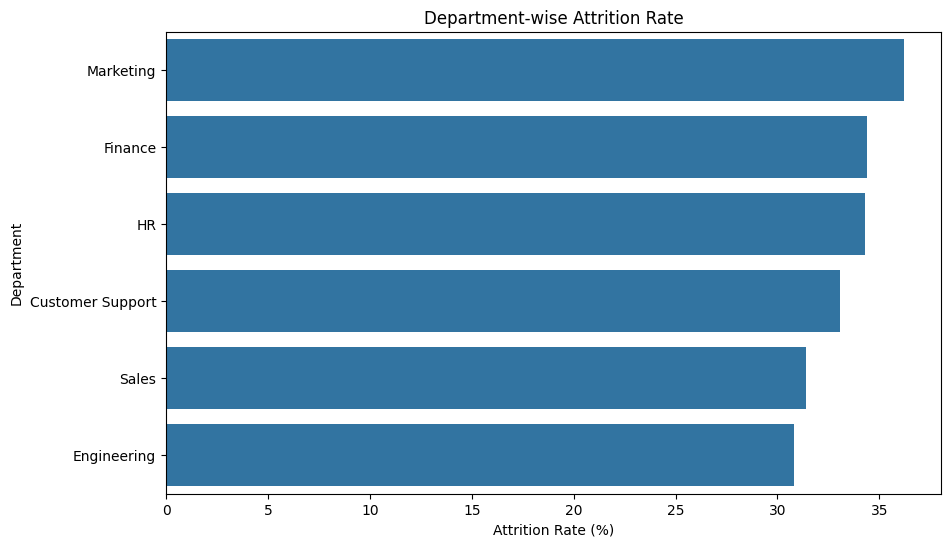

In [8]:
department_rate = (
    df.groupby("Department")["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=department_rate.values,
    y=department_rate.index
)

plt.title("Department-wise Attrition Rate")
plt.xlabel("Attrition Rate (%)")
plt.ylabel("Department")

plt.show()

In [9]:
location_rate = (
    df.groupby("Location")["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

print("Location-wise Attrition Rate:")
print(location_rate)

Location-wise Attrition Rate:
Location
California    39.834025
New York      35.111111
Remote        33.333333
Texas         31.782946
Virginia      30.384615
Washington    30.337079
Name: Attrition, dtype: float64


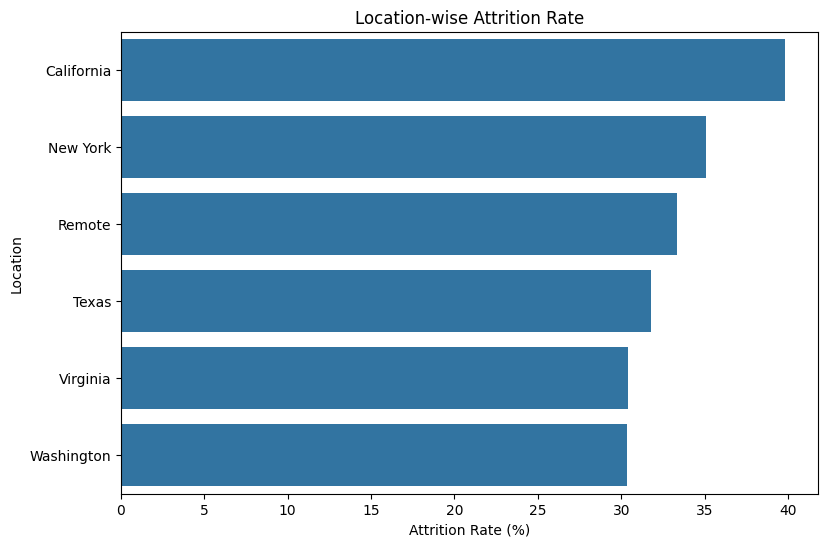

In [10]:
plt.figure(figsize=(9,6))

sns.barplot(
    x=location_rate.values,
    y=location_rate.index
)

plt.title("Location-wise Attrition Rate")
plt.xlabel("Attrition Rate (%)")
plt.ylabel("Location")

plt.show()

In [11]:
hotspot = pd.crosstab(
    [df["Department"], df["Location"]],
    df["Attrition"],
    normalize="index"
) * 100

hotspot = hotspot.reset_index()

hotspot["Attrition_Rate"] = hotspot.get(
    "Yes",
    0
)

hotspot = hotspot.sort_values(
    "Attrition_Rate",
    ascending=False
)

hotspot.head(15)

Attrition,Department,Location,No,Yes,Attrition_Rate
12,Finance,California,47.368421,52.631579,52.631579
24,Marketing,California,51.515152,48.484848,48.484848
26,Marketing,Remote,57.894737,42.105263,42.105263
19,HR,New York,60.465116,39.534884,39.534884
25,Marketing,New York,60.526316,39.473684,39.473684
20,HR,Remote,60.714286,39.285714,39.285714
31,Sales,New York,60.714286,39.285714,39.285714
33,Sales,Texas,60.975610,39.024390,39.024390
18,HR,California,61.702128,38.297872,38.297872
6,Engineering,California,62.500000,37.500000,37.500000


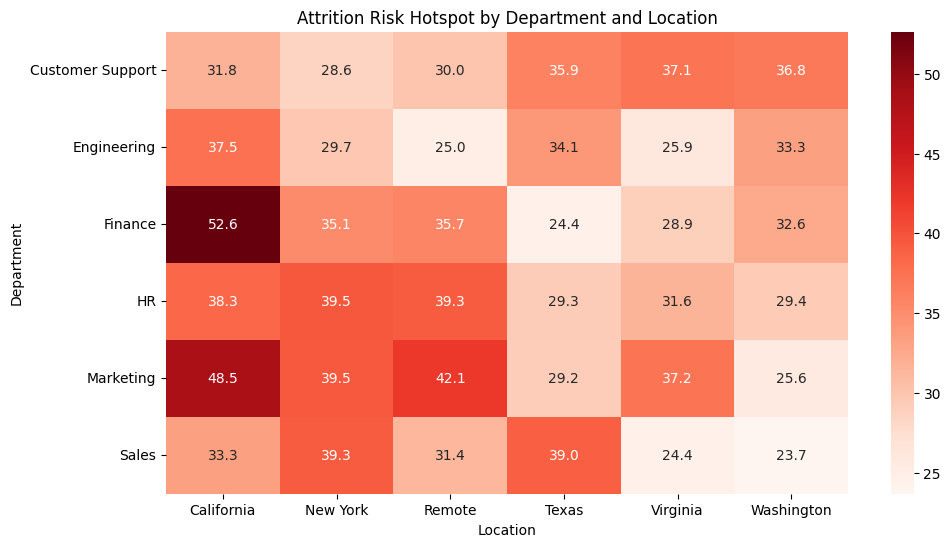

In [12]:
heatmap_data = pd.pivot_table(
    df,
    values="Age",
    index="Department",
    columns="Location",
    aggfunc="count"
)

attrition_heatmap = pd.pivot_table(
    df.assign(
        Attrition_Flag=(
            df["Attrition"] == "Yes"
        ).astype(int)
    ),
    values="Attrition_Flag",
    index="Department",
    columns="Location",
    aggfunc="mean"
) * 100

plt.figure(figsize=(11,6))

sns.heatmap(
    attrition_heatmap,
    annot=True,
    fmt=".1f",
    cmap="Reds"
)

plt.title(
    "Attrition Risk Hotspot by Department and Location"
)

plt.xlabel("Location")
plt.ylabel("Department")

plt.show()

In [13]:
high_risk_hotspots = hotspot[
    hotspot["Attrition_Rate"] >= 20
]

print("High-Risk Workforce Hotspots:")
print(high_risk_hotspots)

High-Risk Workforce Hotspots:
Attrition        Department    Location         No        Yes  Attrition_Rate
12                  Finance  California  47.368421  52.631579       52.631579
24                Marketing  California  51.515152  48.484848       48.484848
26                Marketing      Remote  57.894737  42.105263       42.105263
19                       HR    New York  60.465116  39.534884       39.534884
25                Marketing    New York  60.526316  39.473684       39.473684
20                       HR      Remote  60.714286  39.285714       39.285714
31                    Sales    New York  60.714286  39.285714       39.285714
33                    Sales       Texas  60.975610  39.024390       39.024390
18                       HR  California  61.702128  38.297872       38.297872
6               Engineering  California  62.500000  37.500000       37.500000
28                Marketing    Virginia  62.790698  37.209302       37.209302
4          Customer Support    Vir

In [14]:
overtime_analysis = pd.crosstab(
    df["Overtime"],
    df["Attrition"],
    normalize="index"
) * 100

print(overtime_analysis)

Attrition         No        Yes
Overtime                       
No         78.170478  21.829522
Yes        46.096654  53.903346


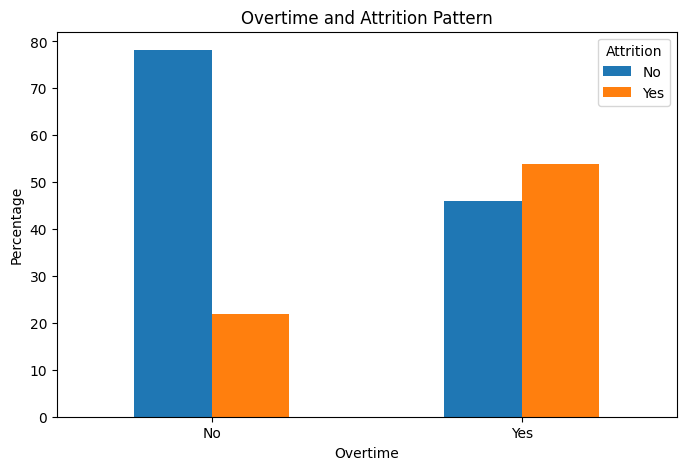

In [15]:
overtime_analysis.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Overtime and Attrition Pattern")
plt.xlabel("Overtime")
plt.ylabel("Percentage")
plt.xticks(rotation=0)

plt.show()

In [16]:
satisfaction_analysis = (
    df.groupby("Job_Satisfaction")["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

print(satisfaction_analysis)

Job_Satisfaction
1    54.117647
2    46.688742
3    20.138889
4    20.069204
5    20.996441
Name: Attrition, dtype: float64


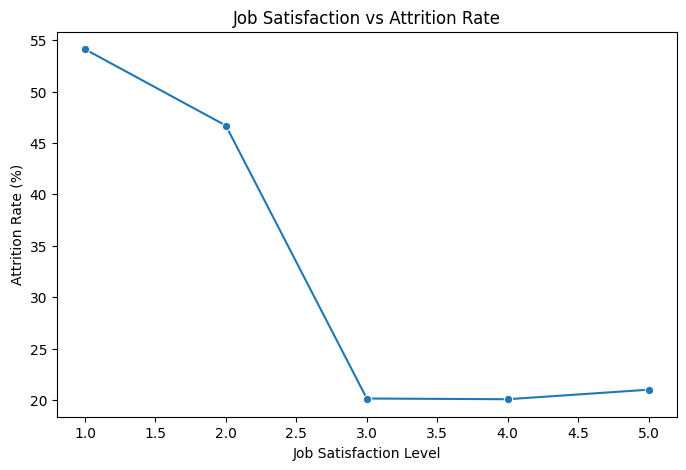

In [17]:
plt.figure(figsize=(8,5))

sns.lineplot(
    x=satisfaction_analysis.index,
    y=satisfaction_analysis.values,
    marker="o"
)

plt.title("Job Satisfaction vs Attrition Rate")
plt.xlabel("Job Satisfaction Level")
plt.ylabel("Attrition Rate (%)")

plt.show()

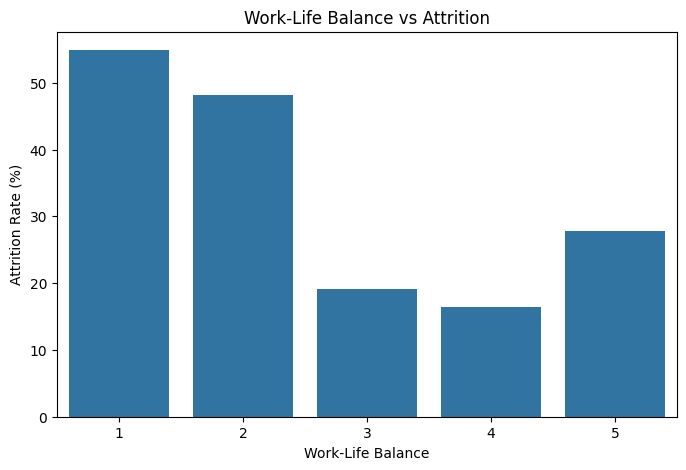

In [18]:
wlb_analysis = (
    df.groupby("Work_Life_Balance")["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=wlb_analysis.index,
    y=wlb_analysis.values
)

plt.title("Work-Life Balance vs Attrition")
plt.xlabel("Work-Life Balance")
plt.ylabel("Attrition Rate (%)")

plt.show()

In [19]:
job_level_analysis = (
    df.groupby("Job_Level")["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

print(job_level_analysis)

Job_Level
Manager    37.142857
Senior     34.422111
Mid        34.381139
Entry      30.022075
Name: Attrition, dtype: float64


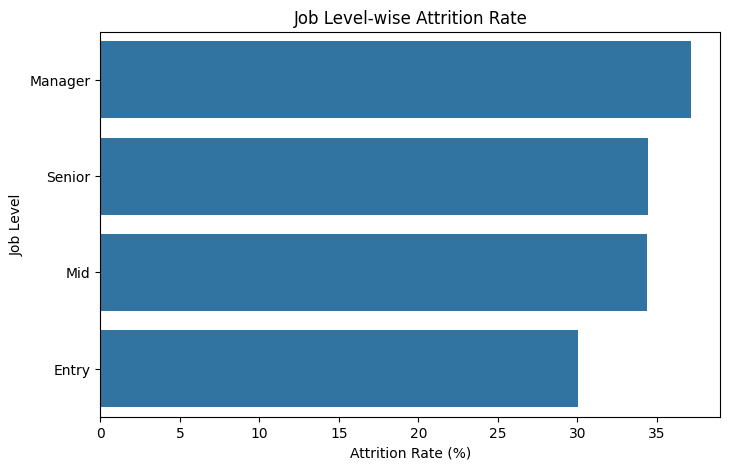

In [20]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=job_level_analysis.values,
    y=job_level_analysis.index
)

plt.title("Job Level-wise Attrition Rate")
plt.xlabel("Attrition Rate (%)")
plt.ylabel("Job Level")

plt.show()

In [21]:
df["Risk_Score"] = (
    (df["Overtime"] == "Yes").astype(int) * 25
    + (df["Job_Satisfaction"] <= 2).astype(int) * 20
    + (df["Work_Life_Balance"] <= 2).astype(int) * 20
    + (df["Years_At_Company"] <= 2).astype(int) * 15
    + (df["Remote_Work"] == "No").astype(int) * 5
)

df["Risk_Score"] = df["Risk_Score"].clip(
    0,
    100
)

df["Risk_Level"] = pd.cut(
    df["Risk_Score"],
    bins=[-1, 30, 60, 100],
    labels=[
        "Low Risk",
        "Medium Risk",
        "High Risk"
    ]
)

df[
    [
        "Employee_ID",
        "Department",
        "Location",
        "Risk_Score",
        "Risk_Level",
        "Attrition"
    ]
].head(15)

,Employee_ID,Department,Location,Risk_Score,Risk_Level,Attrition
0,1001,HR,Remote,25,Low Risk,Yes
1,1002,Finance,Texas,50,Medium Risk,Yes
2,1003,Marketing,Virginia,40,Medium Risk,Yes
3,1004,Finance,New York,60,Medium Risk,Yes
4,1005,Finance,Washington,5,Low Risk,No
5,1006,Sales,Virginia,45,Medium Risk,No
6,1007,Marketing,New York,45,Medium Risk,No
7,1008,Marketing,New York,5,Low Risk,No
8,1009,Marketing,California,70,High Risk,Yes
9,1010,Finance,Washington,5,Low Risk,No


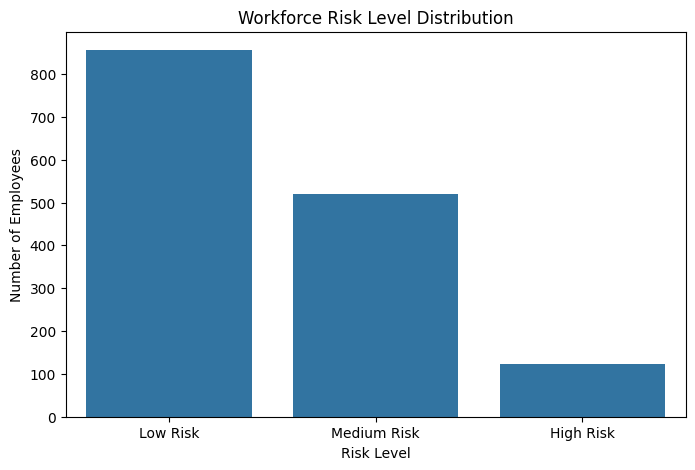

In [22]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Risk_Level",
    order=[
        "Low Risk",
        "Medium Risk",
        "High Risk"
    ]
)

plt.title("Workforce Risk Level Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Employees")

plt.show()

In [23]:
high_risk_employees = df[
    df["Risk_Level"] == "High Risk"
].sort_values(
    "Risk_Score",
    ascending=False
)

print(
    "High-Risk Employees:",
    len(high_risk_employees)
)

high_risk_employees[
    [
        "Employee_ID",
        "Department",
        "Location",
        "Job_Level",
        "Job_Satisfaction",
        "Work_Life_Balance",
        "Overtime",
        "Years_At_Company",
        "Risk_Score",
        "Risk_Level",
        "Attrition"
    ]
].head(20)

High-Risk Employees: 124


,Employee_ID,Department,Location,Job_Level,Job_Satisfaction,Work_Life_Balance,Overtime,Years_At_Company,Risk_Score,Risk_Level,Attrition
109,1110,Marketing,Remote,Senior,2,1,Yes,1,85,High Risk,Yes
104,1105,Engineering,Remote,Mid,1,1,Yes,1,85,High Risk,Yes
138,1139,Marketing,Virginia,Senior,1,1,Yes,2,85,High Risk,Yes
139,1140,Engineering,Virginia,Senior,2,2,Yes,0,85,High Risk,Yes
587,1588,Engineering,California,Senior,1,2,Yes,0,85,High Risk,Yes
637,1638,Engineering,Remote,Senior,1,1,Yes,1,85,High Risk,Yes
665,1666,HR,Texas,Manager,1,2,Yes,2,85,High Risk,Yes
397,1398,Sales,Virginia,Mid,1,1,Yes,2,85,High Risk,Yes
1064,2065,Sales,Remote,Senior,1,2,Yes,1,85,High Risk,Yes
938,1939,Customer Support,Remote,Mid,1,2,Yes,2,85,High Risk,Yes


In [24]:
total_employees = len(df)

total_attrition = (
    df["Attrition"] == "Yes"
).sum()

overall_rate = (
    total_attrition / total_employees
) * 100

highest_department = department_rate.index[0]
highest_department_rate = department_rate.iloc[0]

highest_location = location_rate.index[0]
highest_location_rate = location_rate.iloc[0]

high_risk_count = (
    df["Risk_Level"] == "High Risk"
).sum()

print("=" * 50)
print("WORKFORCE ATTRITION ANALYSIS SUMMARY")
print("=" * 50)

print("Total Employees:", total_employees)

print(
    "Employees with Attrition:",
    total_attrition
)

print(
    "Overall Attrition Rate:",
    round(overall_rate, 2),
    "%"
)

print(
    "Highest Department Attrition:",
    highest_department,
    "(",
    round(highest_department_rate, 2),
    "% )"
)

print(
    "Highest Location Attrition:",
    highest_location,
    "(",
    round(highest_location_rate, 2),
    "% )"
)

print(
    "High-Risk Employees:",
    high_risk_count
)

print("=" * 50)

WORKFORCE ATTRITION ANALYSIS SUMMARY
Total Employees: 1500
Employees with Attrition: 500
Overall Attrition Rate: 33.33 %
Highest Department Attrition: Marketing ( 36.21 % )
Highest Location Attrition: California ( 39.83 % )
High-Risk Employees: 124


In [25]:
df.to_csv(
    "Palo_Alto_Workforce_Attrition_Analysis.csv",
    index=False
)

hotspot.to_csv(
    "Workforce_Risk_Hotspots.csv",
    index=False
)

print("Project files saved successfully!")

Project files saved successfully!


In [26]:
from google.colab import files

files.download(
    "Palo_Alto_Workforce_Attrition_Analysis.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [27]:
files.download(
    "Workforce_Risk_Hotspots.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [28]:
print("""
================================================
PROJECT CONCLUSION
================================================

The Workforce Attrition Patterns and Risk
Hotspot Analysis project analyzes employee
attrition patterns across departments and
locations.

A synthetic workforce dataset was created for
demonstration because no official employee
dataset was provided.

The analysis identifies:

• Overall workforce attrition rate
• Department-wise attrition patterns
• Location-wise attrition patterns
• Department-location risk hotspots
• Overtime and attrition relationship
• Job satisfaction and attrition relationship
• Work-life balance patterns
• Employee-level risk scores

Employees were categorized into Low, Medium,
and High Risk groups.

The analysis can help HR teams understand
where workforce attrition is concentrated and
which employee factors are associated with
higher risk.

================================================
PROJECT COMPLETED
================================================
""")


PROJECT CONCLUSION

The Workforce Attrition Patterns and Risk
Hotspot Analysis project analyzes employee
attrition patterns across departments and
locations.

A synthetic workforce dataset was created for
demonstration because no official employee
dataset was provided.

The analysis identifies:

• Overall workforce attrition rate
• Department-wise attrition patterns
• Location-wise attrition patterns
• Department-location risk hotspots
• Overtime and attrition relationship
• Job satisfaction and attrition relationship
• Work-life balance patterns
• Employee-level risk scores

Employees were categorized into Low, Medium,
and High Risk groups.

The analysis can help HR teams understand
where workforce attrition is concentrated and
which employee factors are associated with
higher risk.

PROJECT COMPLETED

